In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt  # juga impor matplotlib untuk mengelola tampilan plot

In [28]:
pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install --upgrade scikit-learn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install pandas


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
#Menunjukan kolom dan baris
df = pd.read_csv('diabetes.csv')
df.shape
df ['Outcome'].value_counts()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
# Memisahkan fitur dan label
X = df.drop(columns='Outcome', axis=1)
Y = df['Outcome']

print (X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [33]:
print (Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [10]:
# Standarisasi data
scaler = StandardScaler()
scaler.fit(X)

standarized_data = scaler.transform(X)
print (standarized_data)

#maka semua data sudah di transform ke dalam bentuk yang sudah terskala

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [11]:
X = standarized_data
Y = df['Outcome']

In [12]:
print (X)
print (Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [13]:
# Memisahkan data training dan data testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)


In [14]:
print (X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [15]:
# Menciptakan model perceptron
classifier = Perceptron()

In [16]:
# Melatih model
classifier.fit(X_train, Y_train)

Perceptron()

In [17]:
# Evaluasi dengan data training
# Lakukan prediksi dengan data pelatihan
X_train_prediction = classifier.predict(X_train)

# Lakukan prediksi dengan data uji
test_predictions = classifier.predict(X_test)

# Hitung akurasi untuk data pelatihan
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Akurasi data training adalah = ', training_data_accuracy)


Akurasi data training adalah =  0.754071661237785


In [18]:
# Evaluasi dengan data testing
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Akurasi data testing adalah = ', test_data_accuracy)

Akurasi data testing adalah =  0.7532467532467533


In [19]:
pip install seaborn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


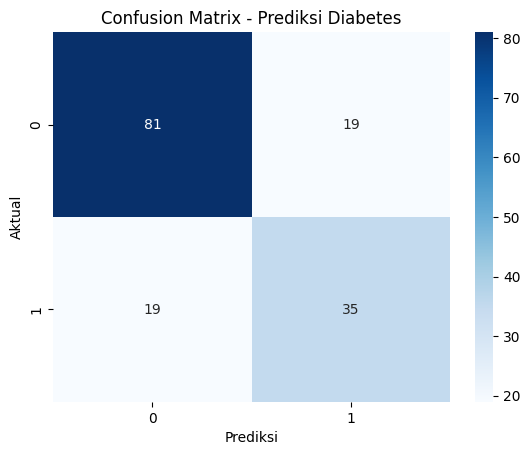

In [20]:
# Matriks kebingungan untuk hasil prediksi
cm = confusion_matrix(Y_test, test_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Prediksi Diabetes')
plt.show()

In [21]:
# Asumsi nama kolom dari dataset asli saat training
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", 
                "BMI", "DiabetesPedigreeFunction", "Age"]

In [41]:
input_data = (1, 85, 66, 29, 0, 26.6, 0.351, 31)

input_data_as_numpy_array = np.array(input_data)

input_data_reshape = input_data_as_numpy_array.reshape(1,-1)

std_data = scaler.transform(input_data_reshape)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
    print('Pasien tidak terkena diabetes')
else :
    print('Pasien terkena diabetes')

[[-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]]
[0]
Pasien tidak terkena diabetes


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
# Laporan klasifikasi yang lebih lengkap
print(classification_report(Y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       100
           1       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [47]:
import pandas as pd
from sklearn.svm import SVC
import pickle

# Memuat dataset diabetes
diabetes_data = pd.read_csv('diabetes.csv')

# Memisahkan fitur dan target
X = diabetes_data.drop(columns=['Outcome'])  # Fitur
y = diabetes_data['Outcome']  # Target

# Melatih model SVC
diabetes_model = SVC()
diabetes_model.fit(X, y)

# Menyimpan model yang dilatih
with open('diabetes_model_fixed.sav', 'wb') as model_file:
    pickle.dump(diabetes_model, model_file)


In [24]:
#Save Model
import pickle

In [25]:
filename = 'diabetes_model.sav'
pickle.dump(classifier, open(filename, 'wb'))